In [2]:
# 1. Importing libraries and dataset
import pandas as pd
import numpy as np

In [3]:
!pip install seaborn


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
# Loading the raw customer data from the local marketing folder
file_path = r"E:\Marketing Analytics\DM Projects\customer_segmentation.csv"
df = pd.read_csv(file_path)
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [6]:
# 2. Exploring data
df.shape

(2240, 29)

In [7]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [9]:
# 3. Cleaning data
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [10]:
df.isna().sum().sum()

np.int64(24)

In [11]:
df = df.dropna()
df.isna().sum().sum()

np.int64(0)

In [12]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [13]:
df["Education"].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [14]:
df["Marital_Status"].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [15]:
# 4. Feature Engineering
# Convert text to datetime, ensuring international format (DD/MM/YYYY) is parsed correctly
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst = True)

In [16]:
# Calculate customer age using their birth year
df["Age"] = 2025 - df["Year_Birth"]
df["Age"]

0       68
1       71
2       60
3       41
4       44
        ..
2235    58
2236    79
2237    44
2238    69
2239    71
Name: Age, Length: 2216, dtype: int64

In [17]:
# Calculate customer total children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]
df["Total_Children"]

0       0
1       2
2       0
3       1
4       1
       ..
2235    1
2236    3
2237    0
2238    1
2239    2
Name: Total_Children, Length: 2216, dtype: int64

In [18]:
# Calculate customer total spending
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [19]:
df["Total_Spending"]

0       1617
1         27
2        776
3         53
4        422
        ... 
2235    1341
2236     444
2237    1241
2238     843
2239     172
Name: Total_Spending, Length: 2216, dtype: int64

In [20]:
# Calculate how many days each customer has been with the company
df["Customer_Since"] = (pd.Timestamp("today") - df["Dt_Customer"]).dt.days
df["Customer_Since"]

0       5049
1       4499
2       4698
3       4525
4       4547
        ... 
2235    4767
2236    4405
2237    4541
2238    4542
2239    5008
Name: Customer_Since, Length: 2216, dtype: int64

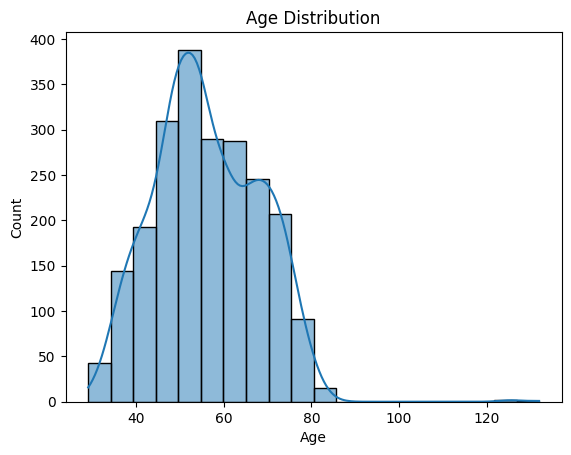

In [21]:
# 5. EDA (Exploratory data analysis)
#Numerical_columns
# Data Exploration: Visualize age distribution and density to check for skewness and outliers

sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

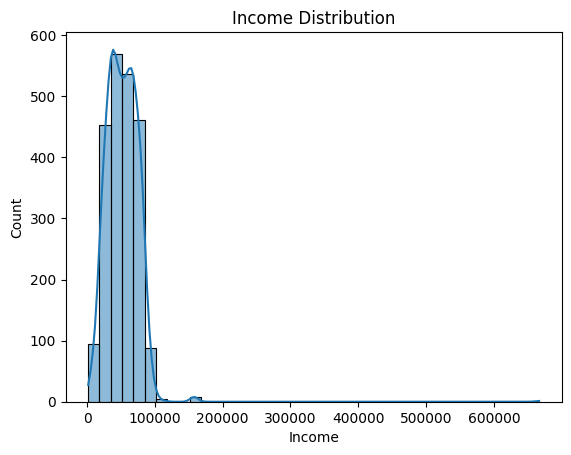

In [22]:
# Data Exploration: Visualize income distribution and density to check for skewness and outliers

sns.histplot(df["Income"], bins = 40, kde = True)
plt.title("Income Distribution")
plt.show()

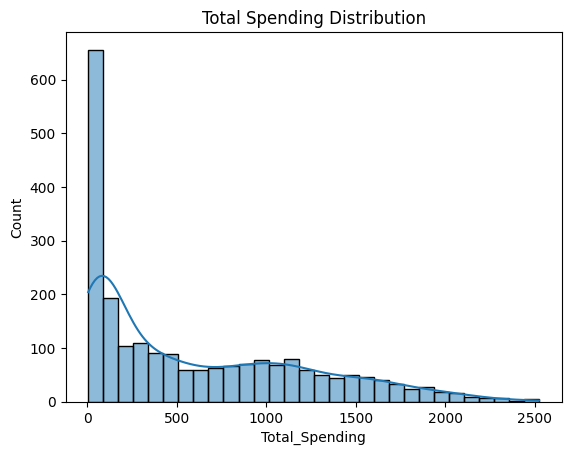

In [23]:
# Data Exploration: Visualize total spending distribution and density to check for skewness and outliers

sns.histplot(df["Total_Spending"], bins=30, kde=True)
plt.title("Total Spending Distribution")
plt.show()

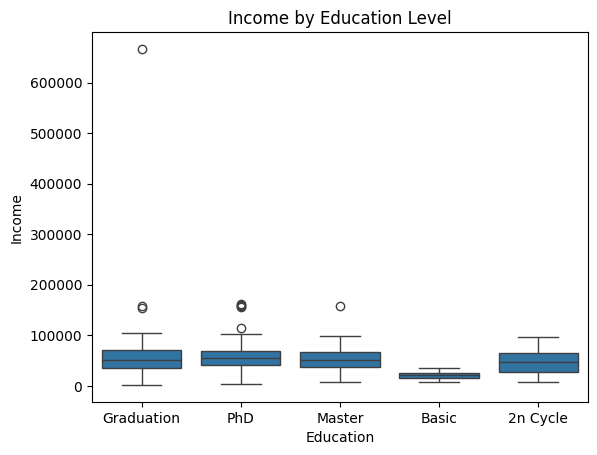

In [24]:
#EDA
#Categorical_columns
# Exploratory Data Analysis: Analyze income variance and detect outliers across different education levels

sns.boxplot(x="Education", y="Income", data=df)
plt.title("Income by Education Level")
plt.show()

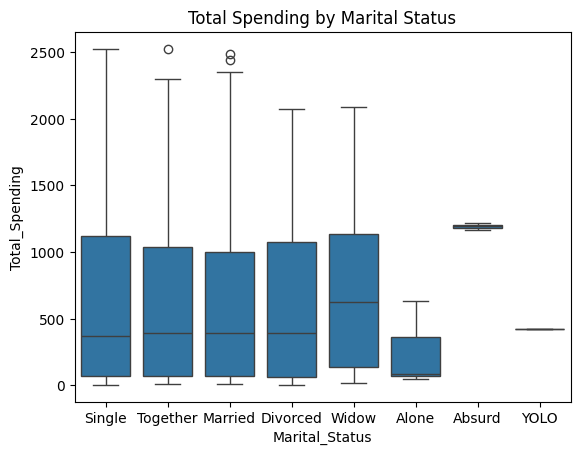

In [25]:
# Exploratory Data Analysis: Analyze total spending variance and detect outliers across different marital status

sns.boxplot(x="Marital_Status", y="Total_Spending", data=df)
plt.title("Total Spending by Marital Status")
plt.show()

In [26]:
#EDA
#Correlation_Analysis
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_Spending', 'Customer_Since'],
      dtype='object')

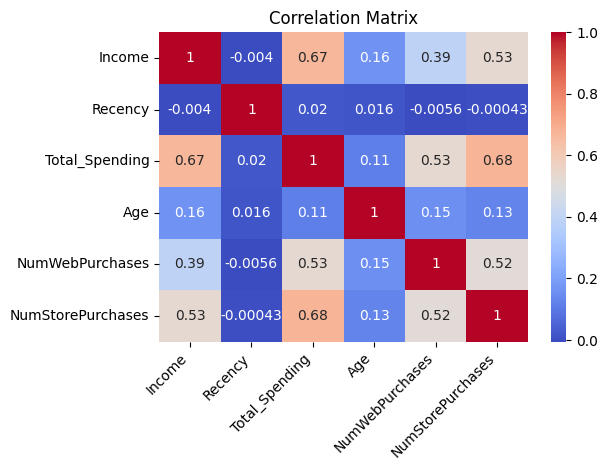

In [27]:
# Feature Selection: Evaluate multicollinearity and identify key linear relationships among customer metrics

corr = df[["Income", "Recency", "Total_Spending", "Age", "NumWebPurchases", "NumStorePurchases"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")

# Rotate x-axis labels by 45 degrees and align them to the right
plt.xticks(rotation=45, ha='right')

# Optional: Rotate y-axis labels to be perfectly horizontal if needed
plt.yticks(rotation=0)

# Adjust layout to make sure labels aren't cut off at the bottom
plt.tight_layout()

plt.show()

In [28]:
# Segment Analysis: Calculate and rank average customer value (spending) by educational attainment

group1 = df.groupby("Education")["Total_Spending"].mean().sort_values(ascending=False)
group1

Education
PhD           676.733888
Graduation    621.686380
Master        609.767123
2n Cycle      494.930000
Basic          81.796296
Name: Total_Spending, dtype: float64

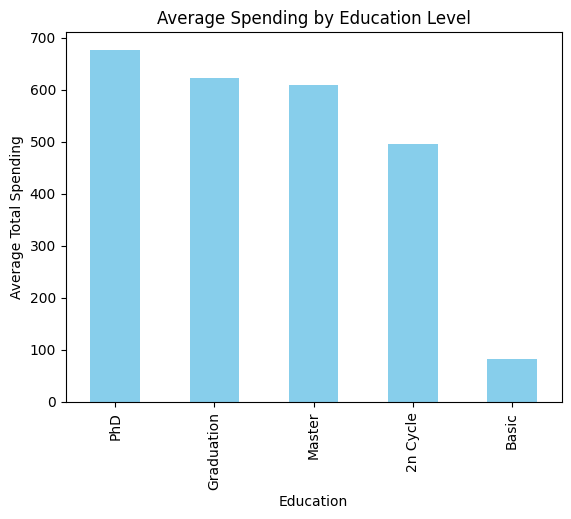

In [29]:
group1.plot(kind="bar", color="skyblue")
plt.title("Average Spending by Education Level")
plt.ylabel("Average Total Spending")
plt.show()

In [30]:
# Behavioral Analysis: Aggregate overall campaign conversions to measure responsiveness by marital demographic

df["AcceptedAny"] = df[["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response"]].sum(axis=1)
df["AcceptedAny"].unique()

array([1, 0, 3, 2, 4, 5])

In [31]:
df["AcceptedAny"] = (df["AcceptedAny"] >= 1).astype(int)
df["AcceptedAny"].unique()

array([1, 0])

In [32]:
group2= df.groupby("Marital_Status")["AcceptedAny"].mean().sort_values(ascending=False)
group2

Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.342105
Alone       0.333333
Single      0.312102
Divorced    0.297414
Married     0.252042
Together    0.251309
Name: AcceptedAny, dtype: float64

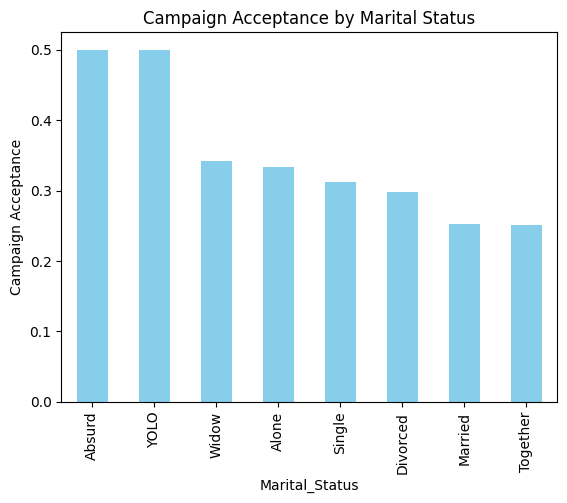

In [33]:
group2.plot(kind="bar", color="skyblue")
plt.title("Campaign Acceptance by Marital Status")
plt.ylabel("Campaign Acceptance")
plt.show()

In [34]:
# Cohort Analysis: Bin customer ages into distinct generations and evaluate their average earning power

bins=[18, 30, 40, 50, 60, 70, 90]
labels = ["18-29", "30-39", "40-49","50-59", "60-69", "70+"]
df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)
df["Age_Group"]

0       60-69
1         70+
2       50-59
3       40-49
4       40-49
        ...  
2235    50-59
2236      70+
2237    40-49
2238    60-69
2239      70+
Name: Age_Group, Length: 2216, dtype: category
Categories (6, object): ['18-29' < '30-39' < '40-49' < '50-59' < '60-69' < '70+']

In [35]:
group3=df.groupby("Age_Group")["Income"].mean().sort_values(ascending=True)
group3

C:\Users\Mo\AppData\Local\Temp\ipykernel_11336\299678217.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group3=df.groupby("Age_Group")["Income"].mean().sort_values(ascending=True)


Age_Group
30-39    46283.028302
18-29    46658.000000
40-49    49224.877034
50-59    50812.913303
60-69    56200.827887
70+      58944.316294
Name: Income, dtype: float64

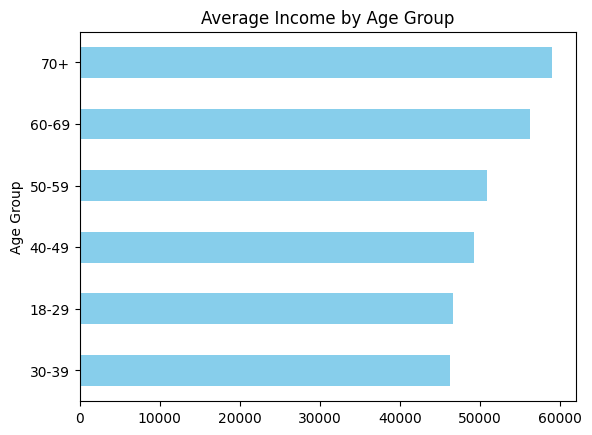

In [36]:
group3.plot(kind="barh", color="skyblue")
plt.title("Average Income by Age Group")
plt.ylabel("Age Group")
plt.show()

In [37]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_Spending', 'Customer_Since',
       'AcceptedAny', 'Age_Group'],
      dtype='object')

In [38]:
# 6. Customer Segmentation

features = ["Age", "Income", "Total_Spending", "NumWebPurchases", "NumStorePurchases", "NumWebVisitsMonth", "Recency"]
X = df[features].copy()
X

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
0,68,58138.0,1617,8,4,7,58
1,71,46344.0,27,1,2,5,38
2,60,71613.0,776,8,10,4,26
3,41,26646.0,53,2,4,6,26
4,44,58293.0,422,5,6,5,94
...,...,...,...,...,...,...,...
2235,58,61223.0,1341,9,4,5,46
2236,79,64014.0,444,8,5,7,56
2237,44,56981.0,1241,2,13,6,91
2238,69,69245.0,843,6,10,3,8


In [39]:
# Data Preprocessing: Scale features to ensure mean=0 and variance=1, preventing feature scale bias in clustering

!pip install scikit-learn

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


array([[ 0.98644293,  0.2340627 ,  1.67548812, ..., -0.55414289,
         0.69323197,  0.31053212],
       [ 1.23680074, -0.23455948, -0.96235832, ..., -1.16951781,
        -0.1315745 , -0.38050944],
       [ 0.31882209,  0.76947764,  0.28024985, ...,  1.29198186,
        -0.54397773, -0.79513438],
       ...,
       [-1.01641959,  0.18809052,  1.05169551, ...,  2.21504423,
         0.28082874,  1.4507507 ],
       [ 1.06989553,  0.67538765,  0.39140438, ...,  1.29198186,
        -0.95638097, -1.41707178],
       [ 1.23680074,  0.02470453, -0.7218    , ..., -0.55414289,
         0.69323197, -0.31140528]], shape=(2216, 7))

In [40]:
# Clustering Optimization: Use the Elbow Method to calculate WCSS across 2 to 9 clusters to find the ideal cluster count

from sklearn.cluster import KMeans

wcss = []

for i in range(2, 10):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [41]:
wcss

[10218.652054158068,
 9007.752707207108,
 8159.286962872505,
 7635.7895873379875,
 7094.4816210383,
 6718.656028058289,
 6283.106595587811,
 5913.211392419129]

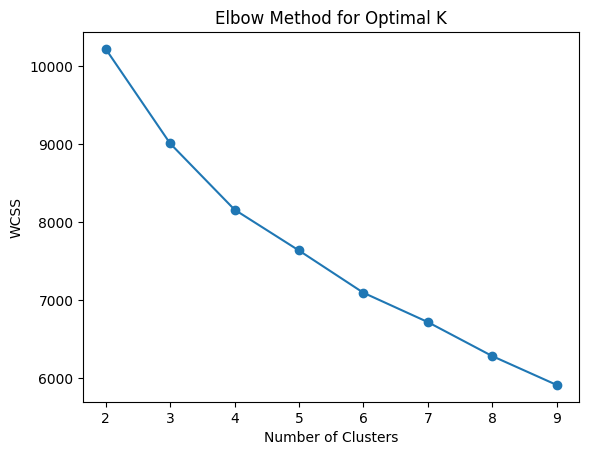

In [42]:
# Model Evaluation: Plot the Elbow curve to visually pinpoint the optimal number of clusters (K) via the inflection point

plt.plot(range(2, 10), wcss, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [43]:
# Model Application: Initialize K-Means with the chosen cluster count
kmeans = KMeans(n_clusters=6)

# Assign group labels back to the dataframe
df["Cluster"] = kmeans.fit_predict(X_scaled)

In [44]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Customer_Since,AcceptedAny,Age_Group,Cluster
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,11,1,68,0,1617,5049,1,60-69,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,3,11,0,71,2,27,4499,0,70+,3
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,3,11,0,60,0,776,4698,0,50-59,5
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,3,11,0,41,1,53,4525,0,40-49,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,11,0,44,1,422,4547,0,40-49,0


In [45]:
# Persona Profiling: Aggregate feature means by cluster to interpret and define unique customer segments

Cluster_Summary = df.groupby("Cluster")[features].mean()
Cluster_Summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,56.852941,60123.106618,929.893382,7.481618,8.286765,6.154412,73.691176
1,47.245696,30478.222222,88.273865,2.057903,2.989045,6.965571,42.859155
2,69.510563,74797.211268,1225.859155,4.461268,8.419014,2.387324,53.003521
3,64.864407,40896.217918,139.426150,2.312349,3.675545,5.704600,61.842615
4,45.870748,79830.965986,1334.278912,4.479592,8.370748,2.459184,47.833333
5,59.949045,58433.089172,757.757962,6.891720,7.391720,6.066879,20.777070


In [46]:
df["Cluster"].value_counts()

Cluster
1    639
3    413
5    314
4    294
2    284
0    272
Name: count, dtype: int64

In [47]:
# Model Evaluation: Visualize the K-Means cluster separation in a reduced 2D feature space using a PCA scatter plot

# Dimensionality Reduction: Project high-dimensional scaled data into 2 principal components for visual evaluation

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
df["PCA1"], df["PCA2"] = pca_data[:, 0], pca_data[:, 1]

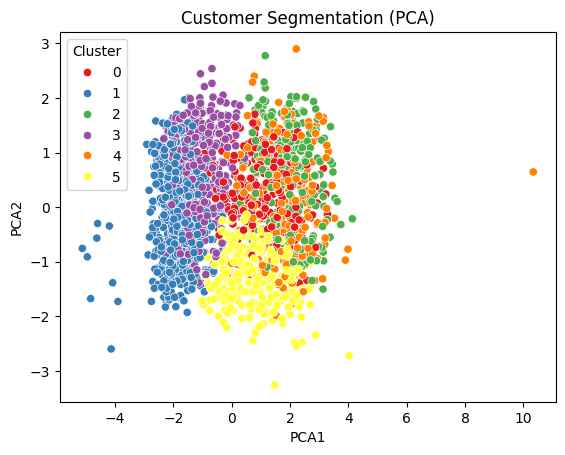

In [48]:
sns.scatterplot(x= "PCA1", y="PCA2", hue="Cluster", data=df, palette="Set1")
plt.title("Customer Segmentation (PCA)")
plt.show()

In [49]:
# Naming clusters

# Cluster 0: Window Shoppers/	High web visits, lowest spending
# Cluster 1: Omnichannel Spenders/	High cross-channel shoppers, older
# Cluster 2: Lapsed Bargain Hunters/	Low spending, high inactivity
# Cluster 3: Affluent Traditionalists/	Wealthy seniors, strictly brick-and-mortar
# Cluster 4: Active Core Customers/	Recent shoppers, balanced spending
# Cluster 5: Elite Young Spenders/	Highest income & spend, youngest group

In [50]:
# Model Persistence: Save the trained clustering model and preprocessing scaler for deployment
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']